# BOmega Algorithm B Update Diagnostics

This notebook focuses on diagnosing B updates in the dag_coordinate_descent_BOmega algorithm (non-epoch version).
For each B update, we record:
1. Original B's ell value
2. Computed delta values
3. Updated ell value after B change

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(r"C:\Users\super\DAG")
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from MEC import is_in_markov_equiv_class
from SCM_data import generate_scm_from_BN
from coordinate_descent.cd_B_Omega import (
    ell, 
    is_DAG, 
    weight_to_adjacency,
    update_Omega_closed_form,
    delta_star_BOmega
)
from coordinate_descent.cd_B import f_B

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\super\DAG\experiments


## 1. Diagnostic Version of BOmega Algorithm (Non-Epoch)

In [2]:
def dag_coordinate_descent_BOmega_B_diagnostic(
    S: np.ndarray,
    Omega_init: np.ndarray,
    T: int = 100,
    seed: int = 0,
    threshold: float = 0.05,
    lambda_l0: float = 0.0,
    k = None,
    dag_tol: float = 1e-8,
    eps_omega: float = 1e-8,
    verbose: bool = True,
    verbose_freq: int = 10,
):
    """
    Diagnostic version of dag_coordinate_descent_BOmega.
    Records detailed information about each B update.
    
    Returns:
        B: Final B matrix
        G: Final adjacency matrix
        final_score: Final objective value
        diagnostic_data: Dictionary with detailed B update information
    """
    np.random.seed(seed)
    d = S.shape[0]
    B = np.zeros((d, d))
    Omega_curr = Omega_init.copy()
    
    # Diagnostic data structure
    diagnostic_data = {
        'iteration': [],
        'i': [],  # row index
        'j': [],  # column index
        'Omega_curr': [],  # current Omega matrix
        'B_before': [],  # B matrix before update
        'B_after': [],  # B matrix after update
        'ell_before_B': [],  # ell value before B update
        'B_ij_before': [],  # B[i,j] before update
        'B_ji_before': [],  # B[j,i] before update
        'delta_ij': [],  # computed delta for B[i,j]
        'delta_ji': [],  # computed delta for B[j,i]
        'chosen_direction': [],  # 'ij', 'ji', or 'none'
        'chosen_delta': [],  # the delta that was chosen
        'B_ij_after': [],  # B[i,j] after update
        'B_ji_after': [],  # B[j,i] after update
        'ell_after_B': [],  # ell value after B update (before Omega update)
        'ell_after_Omega': [],  # ell value after Omega update
        'B_improved': [],  # whether B update improved (decreased) ell
        'Omega_improved': [],  # whether Omega update improved ell
        'B_contribution': [],  # change in ell due to B update
        'Omega_contribution': [],  # change in ell due to Omega update
    }
    
    for t in range(T):
        diagnostic_data['Omega_curr'].append(Omega_curr.copy())
        i, j = np.random.choice(d, 2, replace=False)
        
        # Record state before B update
        ell_before_B = ell(B, Omega_curr, S)
        B_ij_before = B[i, j]
        B_ji_before = B[j, i]
        B_before = B.copy()
        
        # Compute deltas for both directions
        B_half = B.copy()
        B_half[i, j] = 0.0
        B_half[j, i] = 0.0
        
        Eij = np.eye(d)[i][:, None] * np.eye(d)[j][None, :]
        Eji = np.eye(d)[j][:, None] * np.eye(d)[i][None, :]
        
        base_val = ell(B_half, Omega_curr, S)
        
        Delta_ij, Delta_ji = -np.inf, -np.inf
        delta_ij, delta_ji = 0.0, 0.0
        
        # Check i->j direction
        if is_DAG(B_half + Eij, tol=dag_tol, k=k):
            delta_ij = delta_star_BOmega(B_half, Omega_curr, S, i, j)
            Delta_ij = base_val - ell(B_half + delta_ij * Eij, Omega_curr, S) - lambda_l0
        
        # Check j->i direction
        if is_DAG(B_half + Eji, tol=dag_tol, k=k):
            delta_ji = delta_star_BOmega(B_half, Omega_curr, S, j, i)
            Delta_ji = base_val - ell(B_half + delta_ji * Eji, Omega_curr, S) - lambda_l0
        
        # Decide which direction to update
        if Delta_ij < 0 and Delta_ji < 0:
            
            # No improvement
            chosen_direction = 'none'
            chosen_delta = 0.0
            B_new = B_half
        elif Delta_ij > Delta_ji:
            chosen_direction = 'ij'
            chosen_delta = delta_ij
            B_new = B_half + delta_ij * Eij
        else:
            chosen_direction = 'ji'
            chosen_delta = delta_ji
            B_new = B_half + delta_ji * Eji
        
        # Record state after B update
        B = B_new
        ell_after_B = ell(B, Omega_curr, S)
        B_ij_after = B[i, j]
        B_ji_after = B[j, i]
        
        # Update Omega
        Omega_curr = update_Omega_closed_form(B, S, eps=eps_omega)
        ell_after_Omega = ell(B, Omega_curr, S)
        
        # Calculate contributions
        B_contribution = ell_after_B - ell_before_B
        Omega_contribution = ell_after_Omega - ell_after_B
        B_improved = B_contribution <= 0
        Omega_improved = Omega_contribution <= 0
        
        # Save diagnostic data
        diagnostic_data['iteration'].append(t)
        diagnostic_data['B_before'].append(B_before)
        diagnostic_data['B_after'].append(B.copy())
        diagnostic_data['i'].append(i)
        diagnostic_data['j'].append(j)
        diagnostic_data['ell_before_B'].append(ell_before_B)
        diagnostic_data['B_ij_before'].append(B_ij_before)
        diagnostic_data['B_ji_before'].append(B_ji_before)
        diagnostic_data['delta_ij'].append(delta_ij)
        diagnostic_data['delta_ji'].append(delta_ji)
        diagnostic_data['chosen_direction'].append(chosen_direction)
        diagnostic_data['chosen_delta'].append(chosen_delta)
        diagnostic_data['B_ij_after'].append(B_ij_after)
        diagnostic_data['B_ji_after'].append(B_ji_after)
        diagnostic_data['ell_after_B'].append(ell_after_B)
        diagnostic_data['ell_after_Omega'].append(ell_after_Omega)
        diagnostic_data['B_improved'].append(B_improved)
        diagnostic_data['Omega_improved'].append(Omega_improved)
        diagnostic_data['B_contribution'].append(B_contribution)
        diagnostic_data['Omega_contribution'].append(Omega_contribution)
        
        # Verbose output
        if verbose and (t < 10 or t % verbose_freq == 0):
            print(f"\n[Iter {t:04d}] Edge ({i},{j})")
            print(f"  Before: ell={ell_before_B:.6f}, B[{i},{j}]={B_ij_before:.4f}, B[{j},{i}]={B_ji_before:.4f}")
            print(f"  Deltas: δ_ij={delta_ij:.4f}, δ_ji={delta_ji:.4f}")
            print(f"  Chosen: {chosen_direction} with δ={chosen_delta:.4f}")
            print(f"  After B: ell={ell_after_B:.6f} (Δ={B_contribution:+.6f}) {'✓' if B_improved else '✗'}")
            print(f"  After Ω: ell={ell_after_Omega:.6f} (Δ={Omega_contribution:+.6f}) {'✓' if Omega_improved else '✗'}")
            print(f"  Omega = \n{Omega_curr}")
            print(f"  before B = \n{B_before}")
            print(f"  after B = \n{B}")
    
    G = weight_to_adjacency(B, threshold)
    final_score = ell(B, Omega_curr, S)
    
    return B, G, final_score, diagnostic_data

## 2. Generate Test Data

In [3]:
# Use same experiment setup as previous notebooks
experiment = {
    "name": "d=4, A→C, A→D, B→C, B→D",
    "B_true": np.array([
        [0, 0, 2, 3],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ]),
    "N": np.array([2, 4, 3, 5]),
}

# Generate data
n_samples = 5000
seed = 41
B_true = experiment["B_true"]
N = experiment["N"]
d = B_true.shape[0]

data, G_true_gen, _, _ = generate_scm_from_BN(
    B_true.T,
    n_samples=n_samples,
    N=N,
    seed=seed
)
n, d = data.shape
S = data.T @ data / n
score_true = f_B(B_true, S)

print(f"=== Experiment: {experiment['name']} ===")
print(f"Generated {n_samples} samples")
print(f"True score: {score_true:.6f}")
print("Sample covariance matrix S:")
print(S)

=== Experiment: d=4, A→C, A→D, B→C, B→D ===
Generated 5000 samples
True score: 4.794817
Sample covariance matrix S:
[[ 2.02641431e+00 -1.27910195e-02  4.03086012e+00  6.04994955e+00]
 [-1.27910195e-02  3.96378440e+00  1.18663634e+01  1.56596020e+01]
 [ 4.03086012e+00  1.18663634e+01  4.67419564e+01  5.91817453e+01]
 [ 6.04994955e+00  1.56596020e+01  5.91817453e+01  8.51650762e+01]]


## 3. Run Diagnostic Algorithm

In [4]:
# Run diagnostic version of BOmega (non-epoch)
T = 200  # number of random coordinate updates
Omega_init = np.eye(d)

B_est, G_est, final_score, diag_data = dag_coordinate_descent_BOmega_B_diagnostic(
    S,
    Omega_init,
    T=T,
    seed=seed,
    threshold=0.05,
    lambda_l0=0.0,
    verbose=True,
    verbose_freq=179
)

print(f"\n{'='*60}")
print(f"Final Results:")
print(f"  Final score: {final_score:.6f}")
print(f"  True score: {score_true:.6f}")
print(f"  Is in MEC: {is_in_markov_equiv_class(G_est.T, B_true)}")
print(f"\nFinal B matrix:")
print(B_est)


[Iter 0000] Edge (1,2)
  Before: ell=68.948616, B[1,2]=0.0000, B[2,1]=0.0000
  Deltas: δ_ij=2.9937, δ_ji=0.2539
  Chosen: ij with δ=2.9937
  After B: ell=51.186476 (Δ=-17.762139) ✓
  After Ω: ell=6.472775 (Δ=-44.713702) ✓
  Omega = 
[[ 2.02641431  0.          0.          0.        ]
 [ 0.          3.9637844   0.          0.        ]
 [ 0.          0.         11.21767781  0.        ]
 [ 0.          0.          0.         85.16507623]]
  before B = 
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
  after B = 
[[0.         0.         0.         0.        ]
 [0.         0.         2.99369548 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]]

[Iter 0001] Edge (3,2)
  Before: ell=6.472775, B[3,2]=0.0000, B[2,3]=0.0000
  Deltas: δ_ij=0.1444, δ_ji=1.2661
  Chosen: ji with δ=1.2661
  After B: ell=6.032851 (Δ=-0.439923) ✓
  After Ω: ell=5.413280 (Δ=-0.619571) ✓
  Omega = 
[[ 2.02641431  0.          0.          0.        ]
 [ 

## 4. Statistical Analysis of B Updates

In [5]:
# Convert to DataFrame for analysis
df = pd.DataFrame(diag_data)

print("="*80)
print("B Update Statistics")
print("="*80)

# 1. Direction statistics
print("\n1. Update Direction Statistics:")
direction_counts = df['chosen_direction'].value_counts()
print(direction_counts)
print(f"\n  No update (none): {direction_counts.get('none', 0)} / {len(df)} ({direction_counts.get('none', 0)/len(df)*100:.1f}%)")
print(f"  i→j updates: {direction_counts.get('ij', 0)} / {len(df)} ({direction_counts.get('ij', 0)/len(df)*100:.1f}%)")
print(f"  j→i updates: {direction_counts.get('ji', 0)} / {len(df)} ({direction_counts.get('ji', 0)/len(df)*100:.1f}%)")

# 2. Delta statistics
print("\n2. Delta Statistics:")
non_zero_deltas = df[df['chosen_delta'] != 0]
print(f"  Non-zero deltas: {len(non_zero_deltas)} / {len(df)}")
if len(non_zero_deltas) > 0:
    print(f"  Mean delta (non-zero): {non_zero_deltas['chosen_delta'].mean():.6f}")
    print(f"  Median delta (non-zero): {non_zero_deltas['chosen_delta'].median():.6f}")
    print(f"  Max delta: {df['chosen_delta'].max():.6f}")
    print(f"  Min delta (non-zero): {non_zero_deltas['chosen_delta'].min():.6f}")

# 3. Improvement statistics
print("\n3. Improvement Statistics:")
print(f"  B updates that improved: {df['B_improved'].sum()} / {len(df)} ({df['B_improved'].sum()/len(df)*100:.1f}%)")
print(f"  B updates that worsened: {(~df['B_improved']).sum()} / {len(df)} ({(~df['B_improved']).sum()/len(df)*100:.1f}%)")
print(f"  Ω updates that improved: {df['Omega_improved'].sum()} / {len(df)} ({df['Omega_improved'].sum()/len(df)*100:.1f}%)")
print(f"  Ω updates that worsened: {(~df['Omega_improved']).sum()} / {len(df)} ({(~df['Omega_improved']).sum()/len(df)*100:.1f}%)")

# 4. Contribution statistics
print("\n4. Contribution Statistics:")
print(f"  B avg contribution: {df['B_contribution'].mean():+.6f}")
print(f"  B total contribution: {df['B_contribution'].sum():+.6f}")
print(f"  Ω avg contribution: {df['Omega_contribution'].mean():+.6f}")
print(f"  Ω total contribution: {df['Omega_contribution'].sum():+.6f}")

# 5. Edge-specific statistics
print("\n5. Most Frequently Updated Edges:")
edge_updates = df.groupby(['i', 'j']).size().sort_values(ascending=False).head(10)
print(edge_updates)

# 6. Largest delta updates
print("\n6. Largest Delta Updates (Top 10):")
largest_deltas = df.nlargest(10, 'chosen_delta')[['iteration', 'i', 'j', 'chosen_direction', 'chosen_delta', 'B_contribution']]
print(largest_deltas.to_string(index=False))

B Update Statistics

1. Update Direction Statistics:
chosen_direction
ij    100
ji    100
Name: count, dtype: int64

  No update (none): 0 / 200 (0.0%)
  i→j updates: 100 / 200 (50.0%)
  j→i updates: 100 / 200 (50.0%)

2. Delta Statistics:
  Non-zero deltas: 200 / 200
  Mean delta (non-zero): 1.472719
  Median delta (non-zero): 1.389723
  Max delta: 3.000176
  Min delta (non-zero): -0.006312

3. Improvement Statistics:
  B updates that improved: 193 / 200 (96.5%)
  B updates that worsened: 7 / 200 (3.5%)
  Ω updates that improved: 191 / 200 (95.5%)
  Ω updates that worsened: 9 / 200 (4.5%)

4. Contribution Statistics:
  B avg contribution: -0.094318
  B total contribution: -18.863675
  Ω avg contribution: -0.228120
  Ω total contribution: -45.623930

5. Most Frequently Updated Edges:
i  j
2  1    20
0  1    19
1  0    18
3  1    18
0  2    17
   3    17
1  2    17
2  3    17
3  2    17
2  0    16
dtype: int64

6. Largest Delta Updates (Top 10):
 iteration  i  j chosen_direction  chosen

## 5. Visualization: B Update Analysis

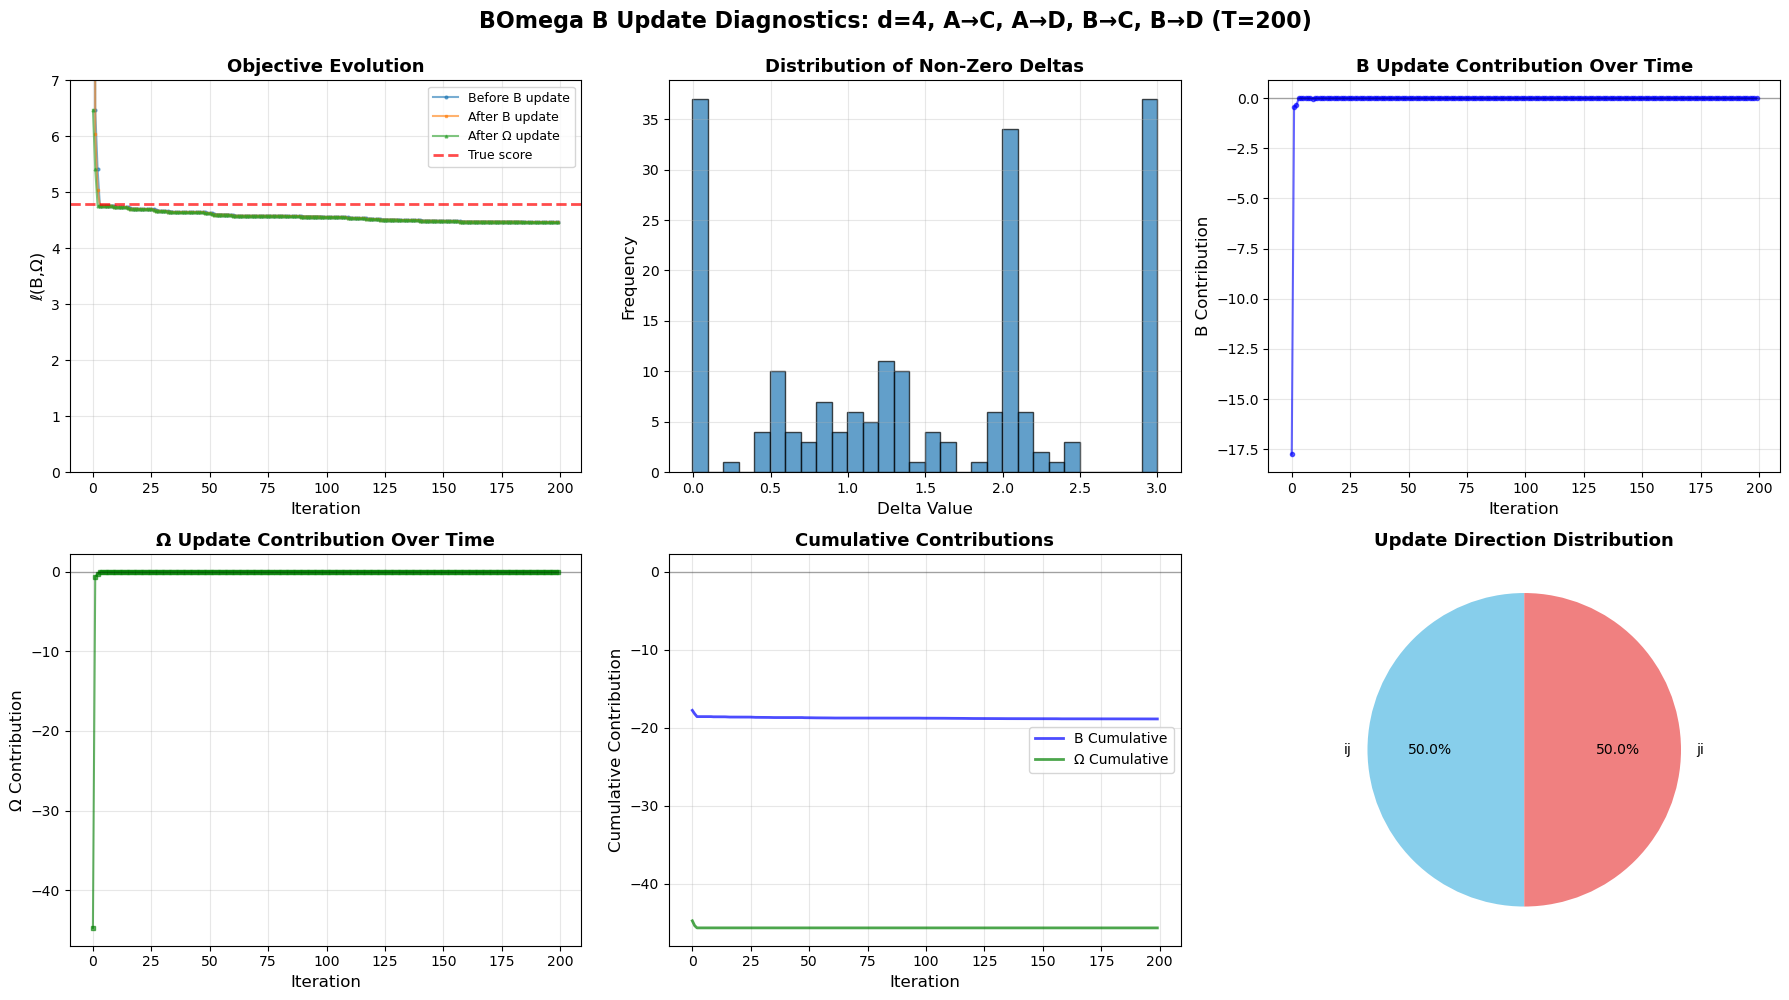

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: ell evolution
ax = axes[0, 0]
iterations = df['iteration'].values
ax.plot(iterations, df['ell_before_B'], 'o-', label='Before B update', markersize=2, alpha=0.6)
ax.plot(iterations, df['ell_after_B'], 's-', label='After B update', markersize=2, alpha=0.6)
ax.plot(iterations, df['ell_after_Omega'], '^-', label='After Ω update', markersize=2, alpha=0.6)
ax.axhline(y=score_true, color='red', linestyle='--', linewidth=2, label='True score', alpha=0.7)
# set xlim
ax.set_ylim(0, 7)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('ℓ(B,Ω)', fontsize=12)
ax.set_title('Objective Evolution', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 2: Delta values distribution
ax = axes[0, 1]
non_zero_df = df[df['chosen_delta'] != 0]
if len(non_zero_df) > 0:
    ax.hist(non_zero_df['chosen_delta'], bins=30, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Delta Value', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Non-Zero Deltas', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, 'No non-zero deltas', ha='center', va='center', fontsize=14)
    ax.set_title('Distribution of Non-Zero Deltas', fontsize=13, fontweight='bold')

# Plot 3: B contribution over time
ax = axes[0, 2]
ax.plot(iterations, df['B_contribution'], 'o-', markersize=3, alpha=0.6, color='blue')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('B Contribution', fontsize=12)
ax.set_title('B Update Contribution Over Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: Omega contribution over time
ax = axes[1, 0]
ax.plot(iterations, df['Omega_contribution'], 's-', markersize=3, alpha=0.6, color='green')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Ω Contribution', fontsize=12)
ax.set_title('Ω Update Contribution Over Time', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 5: Cumulative contributions
ax = axes[1, 1]
B_cumsum = df['B_contribution'].cumsum()
Omega_cumsum = df['Omega_contribution'].cumsum()
ax.plot(iterations, B_cumsum, '-', label='B Cumulative', linewidth=2, alpha=0.7, color='blue')
ax.plot(iterations, Omega_cumsum, '-', label='Ω Cumulative', linewidth=2, alpha=0.7, color='green')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Cumulative Contribution', fontsize=12)
ax.set_title('Cumulative Contributions', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 6: Update direction pie chart
ax = axes[1, 2]
direction_counts = df['chosen_direction'].value_counts()
colors = {'ij': 'skyblue', 'ji': 'lightcoral', 'none': 'lightgray'}
plot_colors = [colors.get(dir, 'gray') for dir in direction_counts.index]
ax.pie(direction_counts.values, labels=direction_counts.index, autopct='%1.1f%%', 
       colors=plot_colors, startangle=90)
ax.set_title('Update Direction Distribution', fontsize=13, fontweight='bold')

plt.suptitle(f'BOmega B Update Diagnostics: {experiment["name"]} (T={T})', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6. Detailed Analysis: Problem Updates

In [7]:
print("="*80)
print("Problem Updates Analysis")
print("="*80)

# Find updates that worsened the score
worsened_B = df[df['B_contribution'] > 0]
worsened_Omega = df[df['Omega_contribution'] > 0]

print(f"\n1. B Updates that Worsened Score: {len(worsened_B)} / {len(df)}")
if len(worsened_B) > 0:
    print("\n   Worst B Updates (Top 10):")
    worst_B = worsened_B.nlargest(10, 'B_contribution')[['iteration', 'i', 'j', 'chosen_direction', 
                                                           'chosen_delta', 'B_contribution', 'ell_before_B', 'ell_after_B']]
    print(worst_B.to_string(index=False))

print(f"\n2. Ω Updates that Worsened Score: {len(worsened_Omega)} / {len(df)}")
if len(worsened_Omega) > 0:
    print("\n   Worst Ω Updates (Top 10):")
    worst_Omega = worsened_Omega.nlargest(10, 'Omega_contribution')[['iteration', 'i', 'j', 
                                                                       'Omega_contribution', 'ell_after_B', 'ell_after_Omega']]
    print(worst_Omega.to_string(index=False))

# Find updates with zero delta (no change chosen)
no_updates = df[df['chosen_direction'] == 'none']
print(f"\n3. Iterations with No Update: {len(no_updates)} / {len(df)}")
if len(no_updates) > 0:
    print("\n   Sample iterations with no update (first 10):")
    print(no_updates[['iteration', 'i', 'j', 'delta_ij', 'delta_ji', 'ell_before_B']].head(10).to_string(index=False))

Problem Updates Analysis

1. B Updates that Worsened Score: 7 / 200

   Worst B Updates (Top 10):
 iteration  i  j chosen_direction  chosen_delta  B_contribution  ell_before_B  ell_after_B
        12  2  0               ji      2.008096    8.881784e-16      4.735549     4.735549
        14  2  3               ij      1.225866    8.881784e-16      4.735549     4.735549
        24  2  0               ji      2.008096    8.881784e-16      4.699511     4.699511
        37  1  2               ij      3.000176    8.881784e-16      4.640095     4.640095
       103  1  3               ij      1.539595    8.881784e-16      4.559664     4.559664
       188  2  3               ij      0.488520    8.881784e-16      4.465204     4.465204
       191  3  2               ji      0.488520    8.881784e-16      4.465204     4.465204

2. Ω Updates that Worsened Score: 9 / 200

   Worst Ω Updates (Top 10):
 iteration  i  j  Omega_contribution  ell_after_B  ell_after_Omega
       196  1  3        3.552714e-

## 7. Export Diagnostic Results

In [8]:
# Save diagnostic data to CSV
output_file = "BOmega_B_updates_diagnostic.csv"
df.to_csv(output_file, index=False)
print(f"Diagnostic results saved to: {output_file}")

# Also save a summary
summary = {
    'total_iterations': len(df),
    'no_update_count': (df['chosen_direction'] == 'none').sum(),
    'ij_update_count': (df['chosen_direction'] == 'ij').sum(),
    'ji_update_count': (df['chosen_direction'] == 'ji').sum(),
    'B_improved_count': df['B_improved'].sum(),
    'B_worsened_count': (~df['B_improved']).sum(),
    'Omega_improved_count': df['Omega_improved'].sum(),
    'Omega_worsened_count': (~df['Omega_improved']).sum(),
    'B_total_contribution': df['B_contribution'].sum(),
    'Omega_total_contribution': df['Omega_contribution'].sum(),
    'final_score': final_score,
    'true_score': score_true,
}

summary_df = pd.DataFrame([summary])
summary_file = "BOmega_B_updates_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"Summary saved to: {summary_file}")

Diagnostic results saved to: BOmega_B_updates_diagnostic.csv
Summary saved to: BOmega_B_updates_summary.csv


Initial ℓ: 68.948616
Final ℓ: 4.461011
Total change: -64.487605
True score: 4.794817


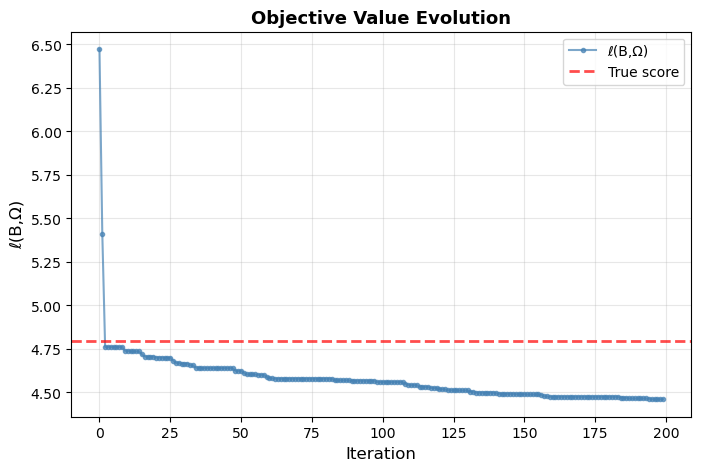

In [9]:
# Simple visualization of ell changes

plt.figure(figsize=(8, 5))

# Plot 1: Overall ell evolution
iterations = df['iteration'].values
plt.plot(iterations, df['ell_after_Omega'], '-o', markersize=3, alpha=0.7, label='ℓ(B,Ω)', color='steelblue')
plt.axhline(y=score_true, color='red', linestyle='--', linewidth=2, label='True score', alpha=0.7)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('ℓ(B,Ω)', fontsize=12)
plt.title('Objective Value Evolution', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)


# Print some statistics
print(f"Initial ℓ: {df['ell_before_B'].iloc[0]:.6f}")
print(f"Final ℓ: {df['ell_after_Omega'].iloc[-1]:.6f}")
print(f"Total change: {df['ell_after_Omega'].iloc[-1] - df['ell_before_B'].iloc[0]:.6f}")
print(f"True score: {score_true:.6f}")

## 9. Statistical Analysis of Parameter 'a'

Analyze the distribution of parameter 'a' across all iterations and edge pairs

Computing 'a' values for chosen directions only...
Computed 'a' for 200 chosen directions

PARAMETER 'a' STATISTICS (CHOSEN DIRECTION ONLY)

Total updates: 200
Updates with chosen direction: 200
Updates with no direction ('none'): 0

Statistics for chosen 'a' values:
  Mean:   0.579302
  Std:    0.957811
  Min:    -0.018938
  Max:    3.677812
  Median: 0.000000

  Count of a ≈ 0 (|a| < 1e-10): 109
  Percentage: 54.50%

CONSTRAINT CHECK: a * δ < 1

Total updates with non-zero δ: 200
  Mean(a * δ): 0.821675
  Max(a * δ):  3.921110
  Min(a * δ):  -0.038028

  Iterations where a*δ >= 0.99: 59
  ⚠ WARNING: Some updates are dangerously close to singularity!
    Max a*δ value: 3.921110



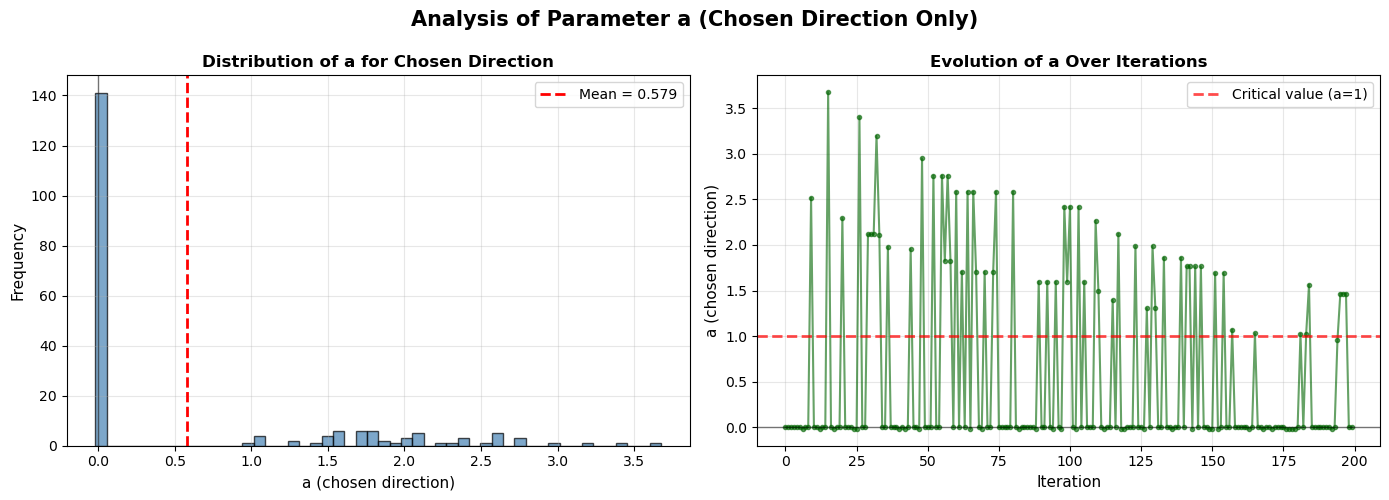


Extreme values of 'a' (chosen direction):

Largest |a| values:
  Iter  15, edge (3,1), dir=ji: a =   3.6778
  Iter  26, edge (1,3), dir=ij: a =   3.4047
  Iter  32, edge (3,1), dir=ji: a =   3.1966
  Iter  48, edge (3,1), dir=ji: a =   2.9504
  Iter  55, edge (3,1), dir=ji: a =   2.7628

Smallest |a| values (closest to zero):
  Iter   0, edge (1,2), dir=ij: a =   0.0000
  Iter   1, edge (3,2), dir=ji: a =   0.0000
  Iter   2, edge (2,0), dir=ji: a =   0.0000
  Iter   3, edge (3,2), dir=ji: a =   0.0000
  Iter  37, edge (1,2), dir=ij: a =   0.0000


In [12]:
# Compute parameter 'a' for the chosen direction only
# a = ej @ (I - B_half.T)^{-1} @ ei

a_values_chosen = []

print("Computing 'a' values for chosen directions only...")

for idx, row in df.iterrows():
    B_before = row['B_before']
    i = row['i']
    j = row['j']
    chosen_dir = row['chosen_direction']
    
    if chosen_dir == 'none':
        a_values_chosen.append(np.nan)
        continue
    
    # Setup
    d = B_before.shape[0]
    I = np.eye(d)
    ei = I[i, :]
    ej = I[j, :]
    
    # B_half: remove both i->j and j->i
    B_half = B_before.copy()
    B_half[i, j] = 0.0
    B_half[j, i] = 0.0
    
    M_half = I - B_half.T
    
    # Compute a for the chosen direction
    if chosen_dir == 'ij':
        # For i->j direction: a = ej @ M_half^{-1} @ ei
        a = ej @ np.linalg.solve(M_half, ei)
    else:  # chosen_dir == 'ji'
        # For j->i direction: a = ei @ M_half^{-1} @ ej
        a = ei @ np.linalg.solve(M_half, ej)
    
    a_values_chosen.append(a)

a_values_chosen = np.array(a_values_chosen)

# Add to dataframe
df['a_chosen'] = a_values_chosen

# Filter out 'none' updates for statistics
valid_a_values = a_values_chosen[~np.isnan(a_values_chosen)]

print(f"Computed 'a' for {len(valid_a_values)} chosen directions\n")

# === Statistical Summary ===
print("="*70)
print("PARAMETER 'a' STATISTICS (CHOSEN DIRECTION ONLY)")
print("="*70)

print(f"\nTotal updates: {len(df)}")
print(f"Updates with chosen direction: {len(valid_a_values)}")
print(f"Updates with no direction ('none'): {len(a_values_chosen) - len(valid_a_values)}")

print(f"\nStatistics for chosen 'a' values:")
print(f"  Mean:   {np.mean(valid_a_values):.6f}")
print(f"  Std:    {np.std(valid_a_values):.6f}")
print(f"  Min:    {np.min(valid_a_values):.6f}")
print(f"  Max:    {np.max(valid_a_values):.6f}")
print(f"  Median: {np.median(valid_a_values):.6f}")

# Count zeros (with tolerance)
zero_tolerance = 1e-10
zero_count = np.sum(np.abs(valid_a_values) < zero_tolerance)
print(f"\n  Count of a ≈ 0 (|a| < {zero_tolerance}): {zero_count}")
print(f"  Percentage: {100 * zero_count / len(valid_a_values):.2f}%")

# Check for constraint violations: a * delta < 1
print("\n" + "="*70)
print("CONSTRAINT CHECK: a * δ < 1")
print("="*70)

valid_chosen = df[df['chosen_direction'] != 'none'].copy()
if len(valid_chosen) > 0:
    valid_chosen['a_times_delta'] = valid_chosen['a_chosen'] * valid_chosen['chosen_delta']
    
    print(f"\nTotal updates with non-zero δ: {len(valid_chosen)}")
    print(f"  Mean(a * δ): {valid_chosen['a_times_delta'].mean():.6f}")
    print(f"  Max(a * δ):  {valid_chosen['a_times_delta'].max():.6f}")
    print(f"  Min(a * δ):  {valid_chosen['a_times_delta'].min():.6f}")
    
    # Check violations
    violations = valid_chosen[valid_chosen['a_times_delta'] >= 0.99]
    print(f"\n  Iterations where a*δ >= 0.99: {len(violations)}")
    if len(violations) > 0:
        print("  ⚠ WARNING: Some updates are dangerously close to singularity!")
        print(f"    Max a*δ value: {valid_chosen['a_times_delta'].max():.6f}")
    else:
        print("  ✓ All updates satisfy constraint with margin")

print("\n" + "="*70)

# === Visualization ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of a (chosen direction)
ax = axes[0]
ax.hist(valid_a_values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=np.mean(valid_a_values), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(valid_a_values):.3f}')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('a (chosen direction)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of a for Chosen Direction', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: a over iterations (chosen direction)
ax = axes[1]
valid_df = df[df['chosen_direction'] != 'none']
ax.plot(valid_df['iteration'], valid_df['a_chosen'], 'o-', markersize=3, alpha=0.6, color='darkgreen')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Critical value (a=1)')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('a (chosen direction)', fontsize=11)
ax.set_title('Evolution of a Over Iterations', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Analysis of Parameter a (Chosen Direction Only)', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

# === Extreme cases ===
print("\nExtreme values of 'a' (chosen direction):")
print("\nLargest |a| values:")
sorted_idx = np.argsort(np.abs(valid_a_values))[::-1]
valid_df_array = df[df['chosen_direction'] != 'none'].reset_index(drop=True)
for k in range(min(5, len(sorted_idx))):
    idx = sorted_idx[k]
    row = valid_df_array.iloc[idx]
    print(f"  Iter {row['iteration']:3d}, edge ({row['i']},{row['j']}), dir={row['chosen_direction']}: a = {valid_a_values[idx]:8.4f}")

print("\nSmallest |a| values (closest to zero):")
sorted_idx = np.argsort(np.abs(valid_a_values))
for k in range(min(5, len(sorted_idx))):
    idx = sorted_idx[k]
    row = valid_df_array.iloc[idx]
    print(f"  Iter {row['iteration']:3d}, edge ({row['i']},{row['j']}), dir={row['chosen_direction']}: a = {valid_a_values[idx]:8.4f}")

DELTA HISTORY (first 20 rows)
 iteration  delta_ij  delta_ji  chosen_delta chosen_direction
         0  2.993695  0.253870      2.993695               ij
         1  0.144445  1.266138      1.266138               ji
         2  0.086236  2.008056      2.008056               ji
         3  0.001797  1.266138      1.266138               ji
         4 -0.003227 -0.006312     -0.006312               ji
         5  3.000175  0.254414      3.000175               ij
         6  2.008096  0.000000      2.008096               ij
         7  0.254414  3.000176      3.000176               ji
         8  0.254414  3.000176      3.000176               ji
         9  0.466995  0.000000      0.466995               ij
        10 -0.006312 -0.003227     -0.006312               ij
        11  0.000602  1.225866      1.225866               ji
        12  0.000000  2.008096      2.008096               ji
        13 -0.003227 -0.006312     -0.006312               ji
        14  1.225866  0.000602      1.22

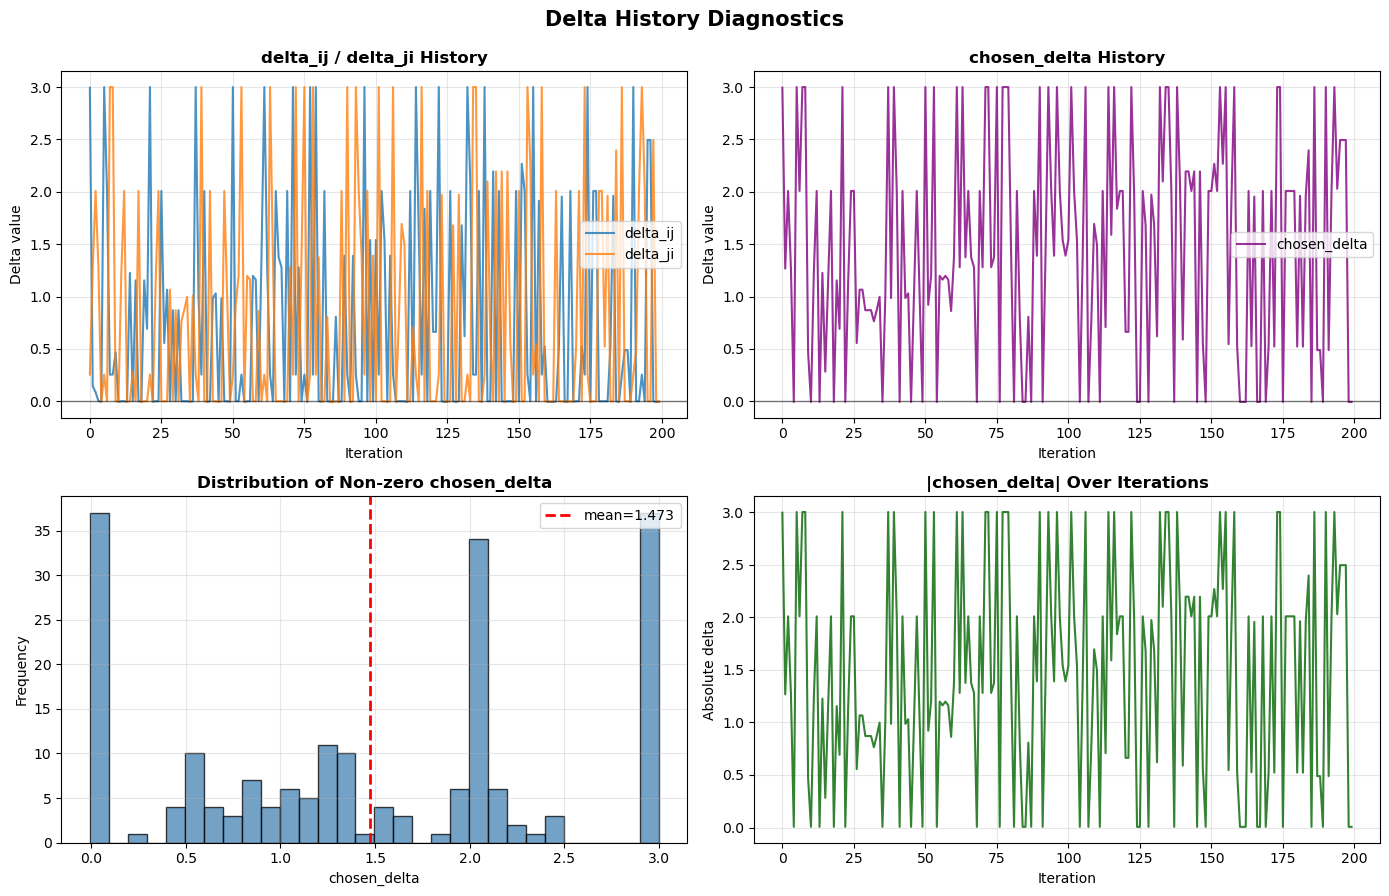

In [13]:
# Delta history output and visualization
required_cols = ['iteration', 'delta_ij', 'delta_ji', 'chosen_delta', 'chosen_direction']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in df: {missing_cols}")

delta_history = df[required_cols].copy()

print("=" * 80)
print("DELTA HISTORY (first 20 rows)")
print("=" * 80)
print(delta_history.head(20).to_string(index=False))

print("\n" + "=" * 80)
print("DELTA SUMMARY")
print("=" * 80)
print(delta_history[['delta_ij', 'delta_ji', 'chosen_delta']].describe().to_string())

non_zero_chosen = delta_history[np.abs(delta_history['chosen_delta']) > 1e-12]
print(f"\nNon-zero chosen_delta count: {len(non_zero_chosen)} / {len(delta_history)}")
if len(non_zero_chosen) > 0:
    print("Top 10 |chosen_delta|:")
    print(
        non_zero_chosen.assign(abs_chosen=np.abs(non_zero_chosen['chosen_delta']))
        .nlargest(10, 'abs_chosen')[['iteration', 'chosen_direction', 'delta_ij', 'delta_ji', 'chosen_delta', 'abs_chosen']]
        .to_string(index=False)
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) delta_ij and delta_ji history
ax = axes[0, 0]
ax.plot(delta_history['iteration'], delta_history['delta_ij'], label='delta_ij', alpha=0.8)
ax.plot(delta_history['iteration'], delta_history['delta_ji'], label='delta_ji', alpha=0.8)
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_title('delta_ij / delta_ji History', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Delta value')
ax.legend()
ax.grid(True, alpha=0.3)

# 2) chosen_delta history
ax = axes[0, 1]
ax.plot(delta_history['iteration'], delta_history['chosen_delta'], color='purple', alpha=0.8, label='chosen_delta')
ax.axhline(0, color='black', linewidth=1, alpha=0.5)
ax.set_title('chosen_delta History', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Delta value')
ax.legend()
ax.grid(True, alpha=0.3)

# 3) chosen_delta distribution (non-zero)
ax = axes[1, 0]
if len(non_zero_chosen) > 0:
    ax.hist(non_zero_chosen['chosen_delta'], bins=30, color='steelblue', edgecolor='black', alpha=0.75)
    ax.axvline(non_zero_chosen['chosen_delta'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"mean={non_zero_chosen['chosen_delta'].mean():.3f}")
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No non-zero chosen_delta', ha='center', va='center', fontsize=12)
ax.set_title('Distribution of Non-zero chosen_delta', fontweight='bold')
ax.set_xlabel('chosen_delta')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)

# 4) absolute chosen_delta over time
ax = axes[1, 1]
ax.plot(delta_history['iteration'], np.abs(delta_history['chosen_delta']), color='darkgreen', alpha=0.8)
ax.set_title('|chosen_delta| Over Iterations', fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Absolute delta')
ax.grid(True, alpha=0.3)

plt.suptitle('Delta History Diagnostics', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()